# Business Problem

- Predict customers who are likely to churn
- Understand key churn drivers
- Help businesses improve customer retention
- Support management with data-driven decisions

## Import Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully")

Libraries loaded successfully


## Load Dataset

In [2]:
df = pd.read_csv(r"D:\cip\Customer_Churn_Project\data\row\data_ecommerce_customer_churn.csv")
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


##  Data Understanding

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

Shape: (3941, 11)

Columns:
 Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   str    
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   str    
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 338.8 KB


In [5]:
df.isnull().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

## Exploratory Data Analysis

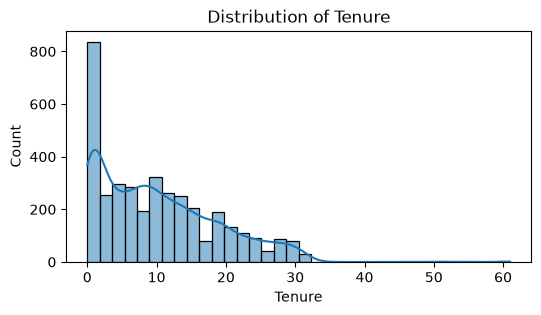

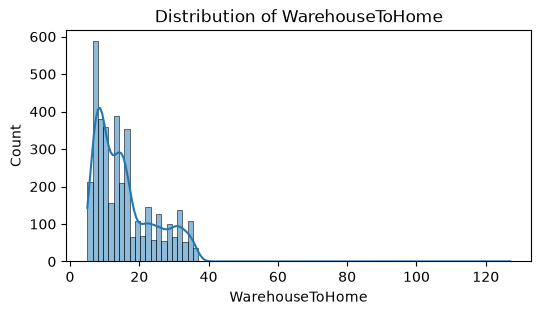

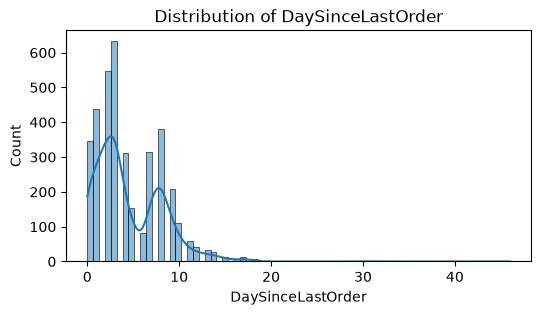

In [6]:
# Histograms for missing-value columns

cols = ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [7]:
print(df[["Tenure", "WarehouseToHome", "DaySinceLastOrder"]].isnull().sum())

print("\nMedian values:")
print("Tenure median =", df["Tenure"].median())
print("Warehouse median =", df["WarehouseToHome"].median())
print("LastOrder median =", df["DaySinceLastOrder"].median())

Tenure               194
WarehouseToHome      169
DaySinceLastOrder    213
dtype: int64

Median values:
Tenure median = 9.0
Warehouse median = 14.0
LastOrder median = 3.0


In [8]:
df["Tenure"] = df["Tenure"].fillna(df["Tenure"].median())
df["WarehouseToHome"] = df["WarehouseToHome"].fillna(df["WarehouseToHome"].median())
df["DaySinceLastOrder"] = df["DaySinceLastOrder"].fillna(df["DaySinceLastOrder"].median())

print(df.isnull().sum())

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


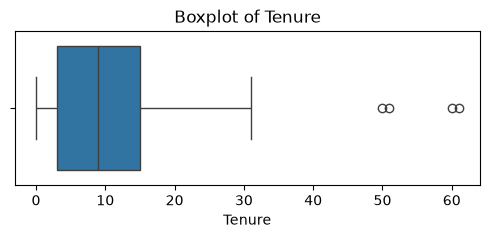

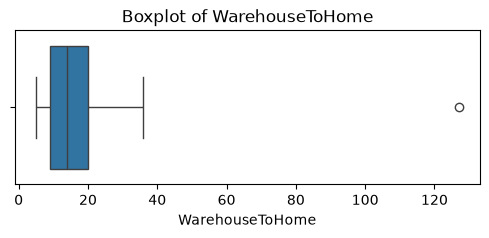

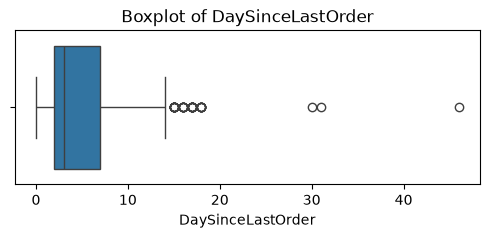

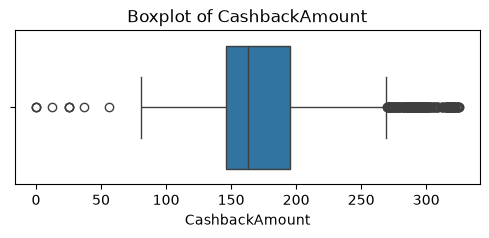

In [9]:
# outlier detecton 
numeric_cols = ["Tenure", "WarehouseToHome", "DaySinceLastOrder", "CashbackAmount"]

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
# IQR capping for WarehouseToHome

Q1 = df["WarehouseToHome"].quantile(0.25)
Q3 = df["WarehouseToHome"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

df["WarehouseToHome"] = np.where(
    df["WarehouseToHome"] > upper,
    upper,
    df["WarehouseToHome"]
)

Lower Bound: -7.5
Upper Bound: 36.5


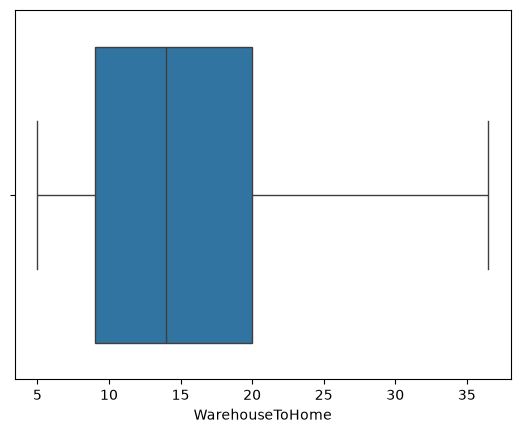

In [11]:
sns.boxplot(x=df["WarehouseToHome"])
plt.show()

## Feature Engineering

In [12]:
# Feature 1: Customer Lifetime Bucket

df["CustomerLifetime"] = pd.cut(
    df["Tenure"],
    bins=[-1, 6, 18, float("inf")],
    labels=["New", "Regular", "Loyal"]
)

df["CustomerLifetime"].value_counts()

CustomerLifetime
Regular    1734
New        1519
Loyal       688
Name: count, dtype: int64

In [13]:
# Feature 2: Distance Bucket

df["DistanceBucket"] = pd.cut(
    df["WarehouseToHome"],
    bins=[0, 10, 20, float("inf")],
    labels=["Near", "Medium", "Far"]
)

df["DistanceBucket"].value_counts()

DistanceBucket
Medium    1621
Near      1368
Far        952
Name: count, dtype: int64

In [14]:
# Feature 3: Complaint Label

df["ComplaintLabel"] = df["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

df["ComplaintLabel"].value_counts()

ComplaintLabel
No Complaint    2828
Complaint       1113
Name: count, dtype: int64

In [15]:
print(df.shape)
df.head()

(3941, 14)


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,CustomerLifetime,DistanceBucket,ComplaintLabel
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0,Regular,Far,No Complaint
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0,Regular,Far,No Complaint
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0,Loyal,Medium,No Complaint
3,20.0,25.0,4,Fashion,3,Divorced,7,0,3.0,230.27,0,Loyal,Far,No Complaint
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0,Loyal,Medium,No Complaint


In [16]:
# Overall churn rate
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

Churn
0    82.897742
1    17.102258
Name: proportion, dtype: float64


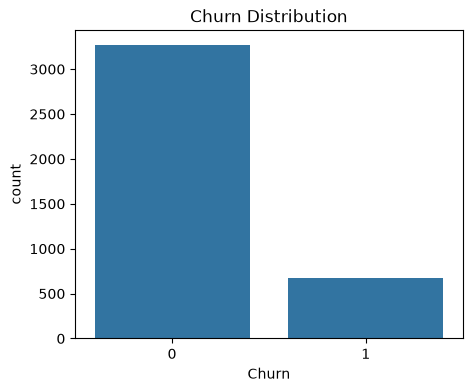

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Hypothesis: Customers who complain churn more.
### Let’s verify.

In [18]:
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({
    "Mobile Phone": "Mobile"})

In [19]:
def get_churn_table(df, column):
    return pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100

In [20]:
product_churn = get_churn_table(df, "PreferedOrderCat")
print(product_churn)

Churn                       0          1
PreferedOrderCat                        
Fashion             83.931624  16.068376
Grocery             95.604396   4.395604
Laptop & Accessory  90.260631   9.739369
Mobile              71.369295  28.630705
Others              93.296089   6.703911


In [21]:
def plot_churn_distribution(df, column_name, figsize=(8,5)):
    
    # Create percentage table
    temp = pd.crosstab(
        df[column_name],
        df["Churn"],
        normalize="index"
    ) * 100

    # Plot
    ax = temp.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    plt.title(f"{column_name} vs Churn (%)")
    plt.xlabel(column_name)
    plt.ylabel("Percentage")
    plt.xticks(rotation=0)

    # Legend outside graph
    plt.legend(
        ["Retained (0)", "Churned (1)"],
        title="Churn",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # Percentage labels
    for container in ax.containers:
        labels = [
            f"{v:.1f}%" if v >= 3 else ""
            for v in container.datavalues
        ]
        ax.bar_label(container, labels=labels, label_type="center")

    plt.tight_layout()
    plt.show()

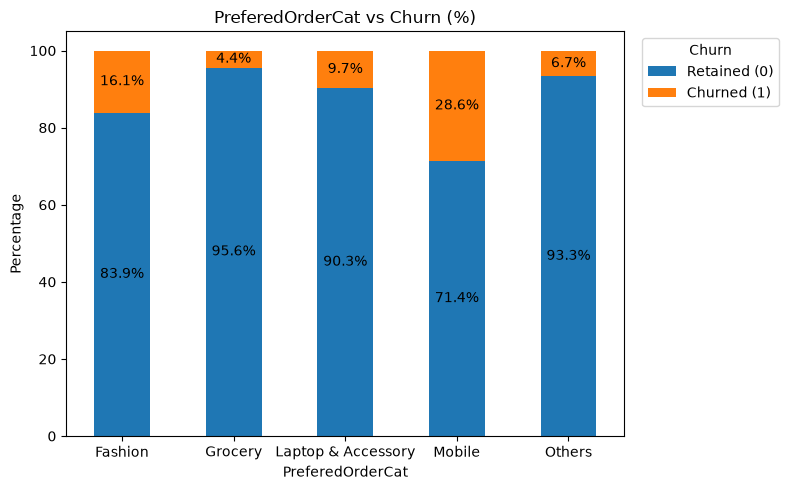

In [22]:
plot_churn_distribution(df, "PreferedOrderCat")

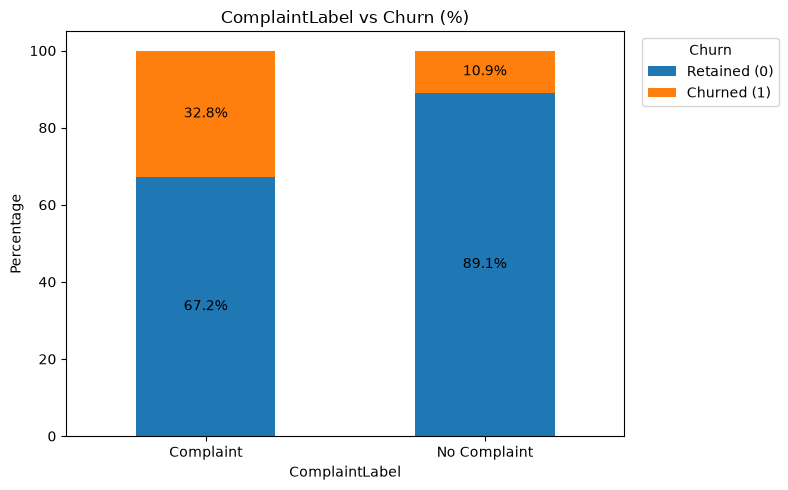

In [23]:
plot_churn_distribution(df, "ComplaintLabel")

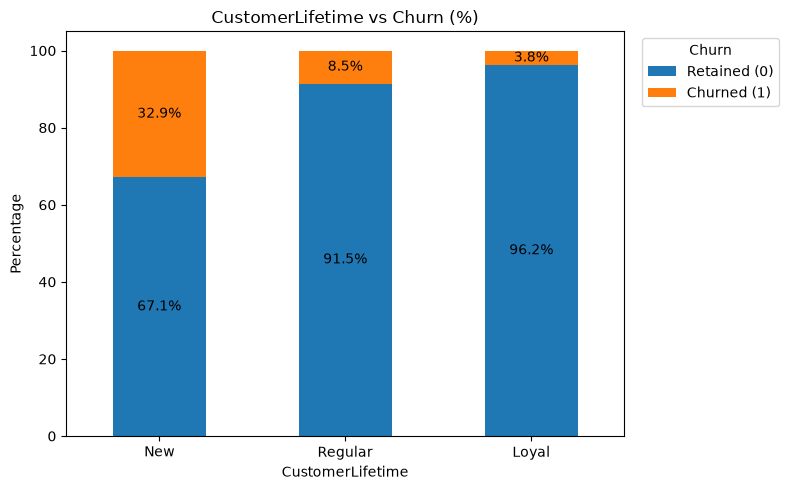

In [24]:
plot_churn_distribution(df, "CustomerLifetime")

# Cashback vs Churn 

# Does higher cashback reduce churn?

In [25]:
cashback_churn = df.groupby("Churn")["CashbackAmount"].mean()
print(cashback_churn.round(2))

Churn
0    180.29
1    159.36
Name: CashbackAmount, dtype: float64


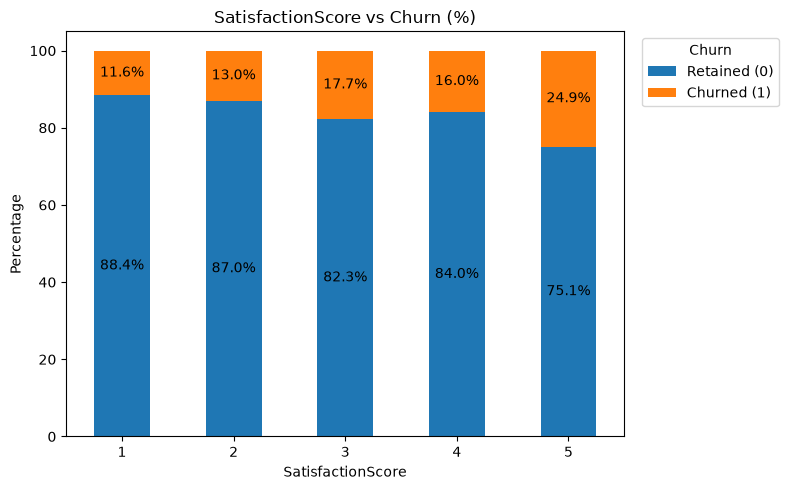

In [26]:
plot_churn_distribution(df, "SatisfactionScore")

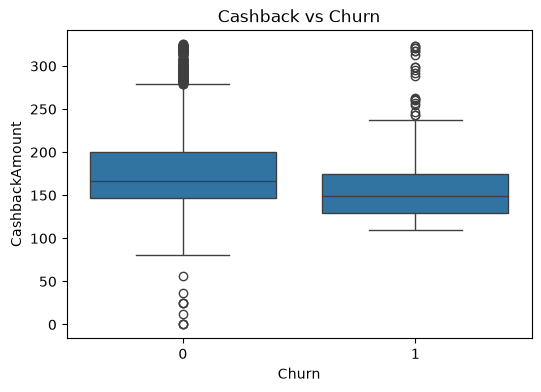

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="CashbackAmount", data=df)
plt.title("Cashback vs Churn")
plt.show()

# Does tenure negatively correlate with churn?
# Does complaint positively correlate with churn?
# Which features matter most?

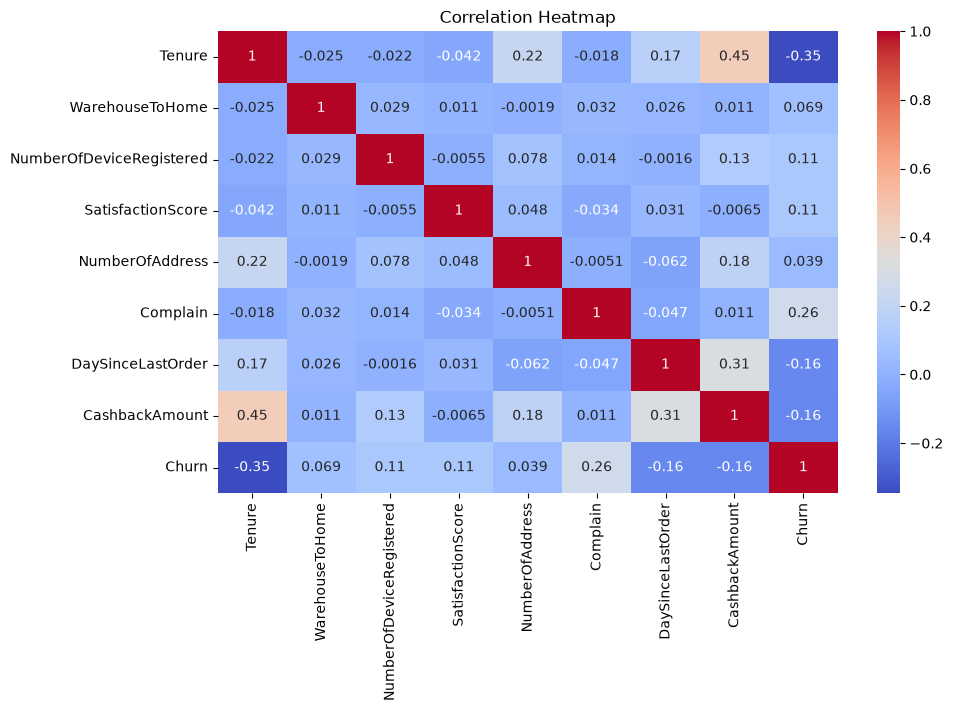

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Does low satisfaction increase churn?

In [29]:
satisfaction_churn =  get_churn_table(df,"SatisfactionScore")
print(satisfaction_churn.round(2))

Churn                  0      1
SatisfactionScore              
1                  88.45  11.55
2                  86.99  13.01
3                  82.27  17.73
4                  84.04  15.96
5                  75.13  24.87


In [30]:
df.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn', 'CustomerLifetime', 'DistanceBucket', 'ComplaintLabel'],
      dtype='str')

Churn
0    180.29
1    159.36
Name: CashbackAmount, dtype: float64


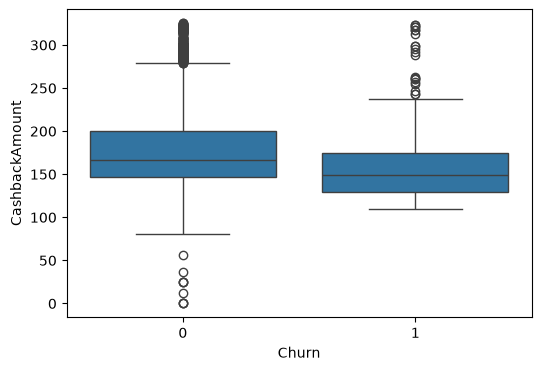

In [31]:
#Cashback vs Churn  
print(df.groupby("Churn")["CashbackAmount"].mean().round(2))

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="CashbackAmount", data=df)
plt.show()

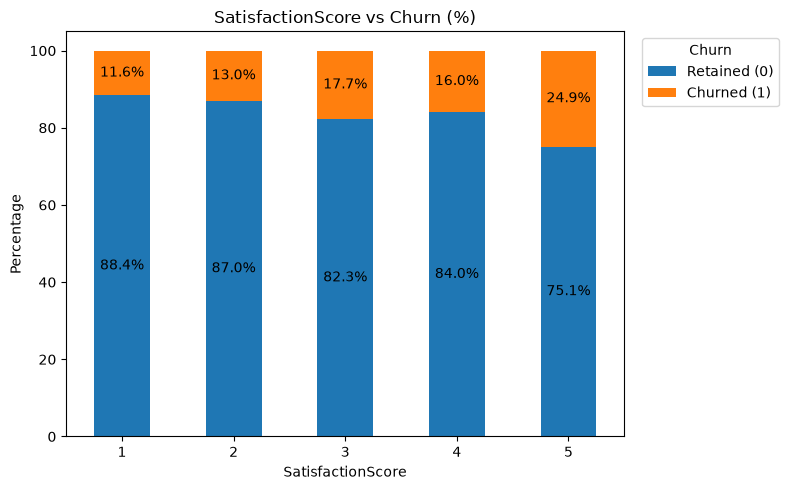

In [32]:
#Satisfaction Score vs Churn
plot_churn_distribution(df, "SatisfactionScore")

# Chi-Square Test — Complaint vs Churn
##  Is complaint statistically related to churn? 

In [33]:
from scipy.stats import chi2_contingency

In [34]:
# Contingency table
contingency_table = pd.crosstab(df["ComplaintLabel"], df["Churn"])
print(contingency_table)

Churn              0    1
ComplaintLabel           
Complaint        748  365
No Complaint    2519  309


In [35]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2, 4))
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 267.8502
P-value: 3.337775674224306e-60
Degrees of freedom: 1


# T-Test
## Is average cashback significantly different between churned and retained customers?

In [36]:
from scipy.stats import ttest_ind

In [37]:
cashback_retained = df[df["Churn"] == 0]["CashbackAmount"]
cashback_churned = df[df["Churn"] == 1]["CashbackAmount"]

print("Retained Mean:", round(cashback_retained.mean(), 2))
print("Churned Mean:", round(cashback_churned.mean(), 2))

Retained Mean: 180.29
Churned Mean: 159.36


In [38]:
t_stat, p_value = ttest_ind(
    cashback_retained,
    cashback_churned,
    equal_var=False   # safer in real projects
)

print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value)

T-statistic: 12.3107
P-value: 6.670293246345247e-33


- H₀ = Mean cashback same in both groups
- H₁ = Mean cashback different 
- p < 0.05 → Reject H₀

# Test 3 — ANOVA 
# Is average cashback different across product categories? 

In [39]:
from scipy.stats import f_oneway 

In [40]:
groups = [
    group["CashbackAmount"].values
    for name, group in df.groupby("PreferedOrderCat")
]

In [41]:
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("P-value:", p_value)

F-statistic: 5277.1928
P-value: 0.0


- H₀ :All category means equal   (μ1 = μ2 = μ3 = ... = μn)
- H₁ :At least one category mean differs

# MACHINE LEARNING 

In [42]:
df_model = df.drop(columns=["ComplaintLabel"])

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]
print(X.shape)
print(y.shape)
print(X.columns)

(3941, 12)
(3941,)
Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'CustomerLifetime', 'DistanceBucket'],
      dtype='str')


## As categories have no order so we are doing onehot encoding 

In [43]:
# Identify categorical columns
categorical_cols = [
    "PreferedOrderCat",
    "MaritalStatus",
    "CustomerLifetime",
    "DistanceBucket"
]

# One-hot encoding
X_encoded = pd.get_dummies(X,columns=categorical_cols,drop_first=True)

print("Before Encoding:", X.shape)
print("After Encoding:", X_encoded.shape)

Before Encoding: (3941, 12)
After Encoding: (3941, 18)


In [44]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3152, 18)
X_test : (789, 18)
y_train: (3152,)
y_test : (789,)


In [45]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on train, transform train
X_train_scaled = scaler.fit_transform(X_train)

# Transform test using same scaler
X_test_scaled = scaler.transform(X_test)

print("Train Scaled Shape:", X_train_scaled.shape)
print("Test Scaled Shape :", X_test_scaled.shape)

Train Scaled Shape: (3152, 18)
Test Scaled Shape : (789, 18)


# Model 1 — Logistic Regression

In [46]:
# Step 1 - Train Model 

from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [47]:
# Step 2 — Prediction
# Predict class labels
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities
y_pred_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed")

Prediction completed


In [48]:
# Step 3 — Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8758
Precision: 0.7126
Recall   : 0.4593
F1 Score : 0.5586


# Balanced Logistic Regression 

In [49]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(class_weight="balanced",random_state=42)

# Train model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [50]:
# Step 2 — Prediction
# Predict class labels
y_pred = log_model.predict(X_test_scaled)

# Predict probabilities
y_pred_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction completed")

Prediction completed


In [51]:
# Step 3 — Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8124
Precision: 0.4726
Recall   : 0.8296
F1 Score : 0.6022


# Model 2 — Random Forest 

## Step 1 — Train Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


## Step 2 — Prediction

In [53]:
y_pred_rf = rf_model.predict(X_test)

print("Prediction completed")

Prediction completed


## Step 3 — Evaluation

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))

Accuracy : 0.9328
Precision: 0.7971
Recall   : 0.8148
F1 Score : 0.8059


# Feature Importance 

## Step 1 — Extract Importance Scores

In [55]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                     Feature  Importance
0                     Tenure    0.268627
7             CashbackAmount    0.139049
1            WarehouseToHome    0.078117
5                   Complain    0.072085
4            NumberOfAddress    0.068628
6          DaySinceLastOrder    0.068066
3          SatisfactionScore    0.061971
10   PreferedOrderCat_Mobile    0.039573
2   NumberOfDeviceRegistered    0.038296
14  CustomerLifetime_Regular    0.034010


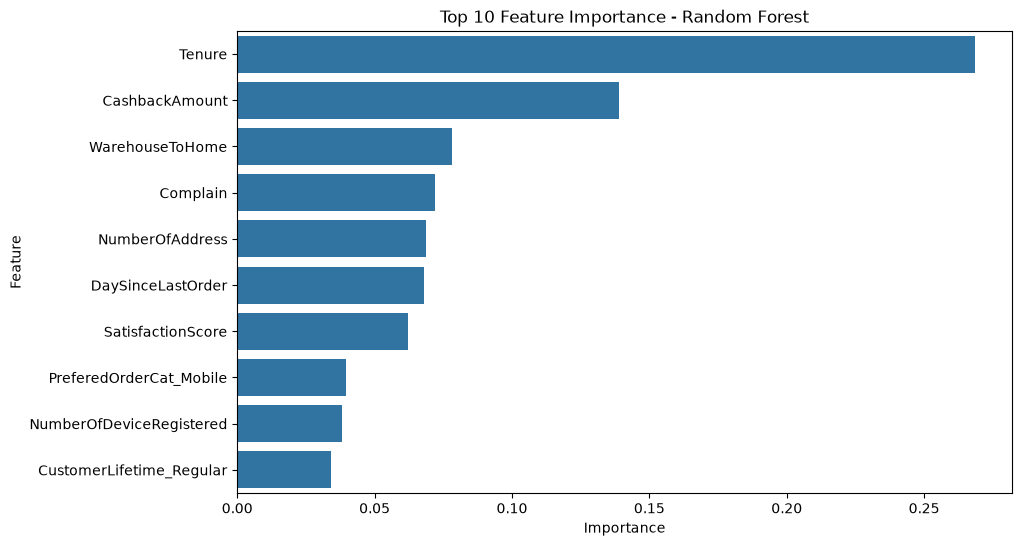

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.show()

# confusion matrix

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[626  28]
 [ 25 110]]


# Model 3 : XGBoost 

In [58]:
# installing 
! pip install xgboost

In [59]:
# Initialize model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Prediction completed")


Prediction completed


In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))

Accuracy : 0.9455
Precision: 0.8966
Recall   : 0.7704
F1 Score : 0.8287


In [61]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[642  12]
 [ 31 104]]


In [62]:
comparison = pd.DataFrame({
    "Model": ["Logistic", "Balanced Logistic", "Random Forest", "XGBoost"],
    "Accuracy": [0.8758, 0.8124, 0.9392, accuracy_xgb],
    "Precision": [0.7126, 0.4726, 0.8175, precision_xgb],
    "Recall": [0.4593, 0.8296, 0.8296, recall_xgb],
    "F1 Score": [0.5586, 0.6022, 0.8235, f1_xgb]
})

print(comparison)

               Model  Accuracy  Precision   Recall  F1 Score
0           Logistic  0.875800   0.712600  0.45930  0.558600
1  Balanced Logistic  0.812400   0.472600  0.82960  0.602200
2      Random Forest  0.939200   0.817500  0.82960  0.823500
3            XGBoost  0.945501   0.896552  0.77037  0.828685


# Exporting  the final cleaned dataset.

In [63]:
print(df.shape)
print(df.columns.tolist())

(3941, 14)
['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount', 'Churn', 'CustomerLifetime', 'DistanceBucket', 'ComplaintLabel']


In [64]:
df_powerbi = df.drop(columns=["ComplaintLabel"])

df_powerbi.to_csv(
    r"D:\cip\Customer_Churn_Project\data\processed\customer_churn_final.csv",
    index=False
)

print("Export successful")

Export successful


In [65]:
import os
print(os.getcwd())

C:\Users\Chittaranjan


In [70]:
feature_importance.to_csv(
    r"D:\cip\Customer_Churn_API\data\processed\feature_importance.csv",
    index=False
)
print("Export successful")

Export successful


In [ ]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        0.8758,
        0.8124,
        0.9392,
        0.9455
    ],

    "Precision": [
        0.7126,
        0.4726,
        0.8175,
        0.8966
    ],

    "Recall": [
        0.4593,
        0.8296,
        0.8296,
        0.7704
    ],

    "F1 Score": [
        0.5586,
        0.6022,
        0.8235,
        0.8287
    ]
})

model_comparison

In [72]:
model_comparison.to_csv(
    r"D:\cip\Customer_Churn_API\data\processed\model_comparison.csv",
    index=False
)

print("Model Comparison CSV Saved Successfully")

NameError: name 'model_comparison' is not defined

In [73]:
import pandas as pd

confusion_matrix_df = pd.DataFrame({
    "Actual": [
        "No Churn",
        "Churn"
    ],

    "Predicted: No Churn": [
        629,
        23
    ],

    "Predicted: Churn": [
        25,
        112
    ]
})

confusion_matrix_df

,Actual,Predicted: No Churn,Predicted: Churn
0,No Churn,629,25
1,Churn,23,112


In [74]:
confusion_matrix_df.to_csv(
    r"D:\cip\Customer_Churn_API\data\processed\confusion_matrix.csv",
    index=False
)

print("Confusion Matrix CSV Saved Successfully")

Confusion Matrix CSV Saved Successfully
